<a href="https://colab.research.google.com/github/mundundan-star/online-retail-customer-analytics/blob/main/3.0%20Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [110]:

!pip install boto3
import boto3
import os
import sys
import importlib
from google.colab import userdata

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, inspect, text
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from google.colab import userdata

from sklearn.pipeline import Pipeline, make_pipeline
import joblib

engine = create_engine(userdata.get("NEON_DATABASE_URL"))
extract_query = """
SELECT *
FROM v_clean_sales_analytics
WHERE "InvoiceDate" <= '2011-08-31'
"""
df = pd.read_sql(text(extract_query), con = engine)

# Intializing s3 client with credentials

s3 = boto3.client(
    "s3",
    aws_access_key_id = userdata.get('AWS_ACCESS_KEY_ID'),
    aws_secret_access_key = userdata.get('AWS_SECRET_ACCESS_KEY'),
    region_name = 'eu-north-1'
)

bucket_name = 'sales-data-analytics-portfolio-2026'

s3.download_file(bucket_name, 'functions/feature_engineering.py', 'feature_engineering.py')
print('\nSuccessfully downloaded feature engineering function from Amazon Web Services')

s3.download_file(bucket_name, 'functions/segmentation_features.py','segmentation_features.py')
print('\nSuccessfully downloaded segmentation features function from Amazon Web Services')


sys.path.append(os.getcwd())
import feature_engineering
import segmentation_features

importlib.reload(feature_engineering)
importlib.reload(segmentation_features)

from feature_engineering import feature_engineering
from segmentation_features import segmentation_features

engine = create_engine(userdata.get("NEON_DATABASE_URL"))

query = """
SELECT *
FROM v_clean_sales_analytics
WHERE "InvoiceDate" <= '2011-08-31'
"""

df_all = pd.read_sql(text(query), con = engine)

df = feature_engineering(df_all)
cohort_df = df[["CustomerID","CohortMonth"]]
df = segmentation_features(df)
df = df[df["TotalRevenue"] < df["TotalRevenue"].quantile(0.95)]

print('Preview of Features')
print(df.info())

print("\nPreview of Customer Segmentation Features")
df


Successfully downloaded feature engineering function from Amazon Web Services

Successfully downloaded segmentation features function from Amazon Web Services
Preview of Features
<class 'pandas.core.frame.DataFrame'>
Index: 3151 entries, 1 to 3316
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        3151 non-null   float64
 1   Tenure            3151 non-null   int64  
 2   ObservedLifeSpan  3151 non-null   int64  
 3   TotalRevenue      3151 non-null   float64
 4   Recency           3151 non-null   int64  
 5   ProductDiversity  3151 non-null   int64  
 6   Frequency         3151 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 196.9 KB
None

Preview of Customer Segmentation Features


,CustomerID,Tenure,ObservedLifeSpan,TotalRevenue,Recency,ProductDiversity,Frequency
1,12347.0,268,239,2790.86,30,82,5
2,12348.0,259,111,1487.24,149,22,3
3,12350.0,211,1,334.40,211,17,1
4,12352.0,197,35,1561.81,163,26,4
5,12353.0,105,1,89.00,105,4,1
...,...,...,...,...,...,...,...
3312,18280.0,178,1,180.60,178,10,1
3313,18281.0,81,1,80.82,81,7,1
3314,18282.0,27,1,100.21,27,7,1
3315,18283.0,238,190,951.93,49,183,8


/tmp/ipykernel_682/2836669933.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


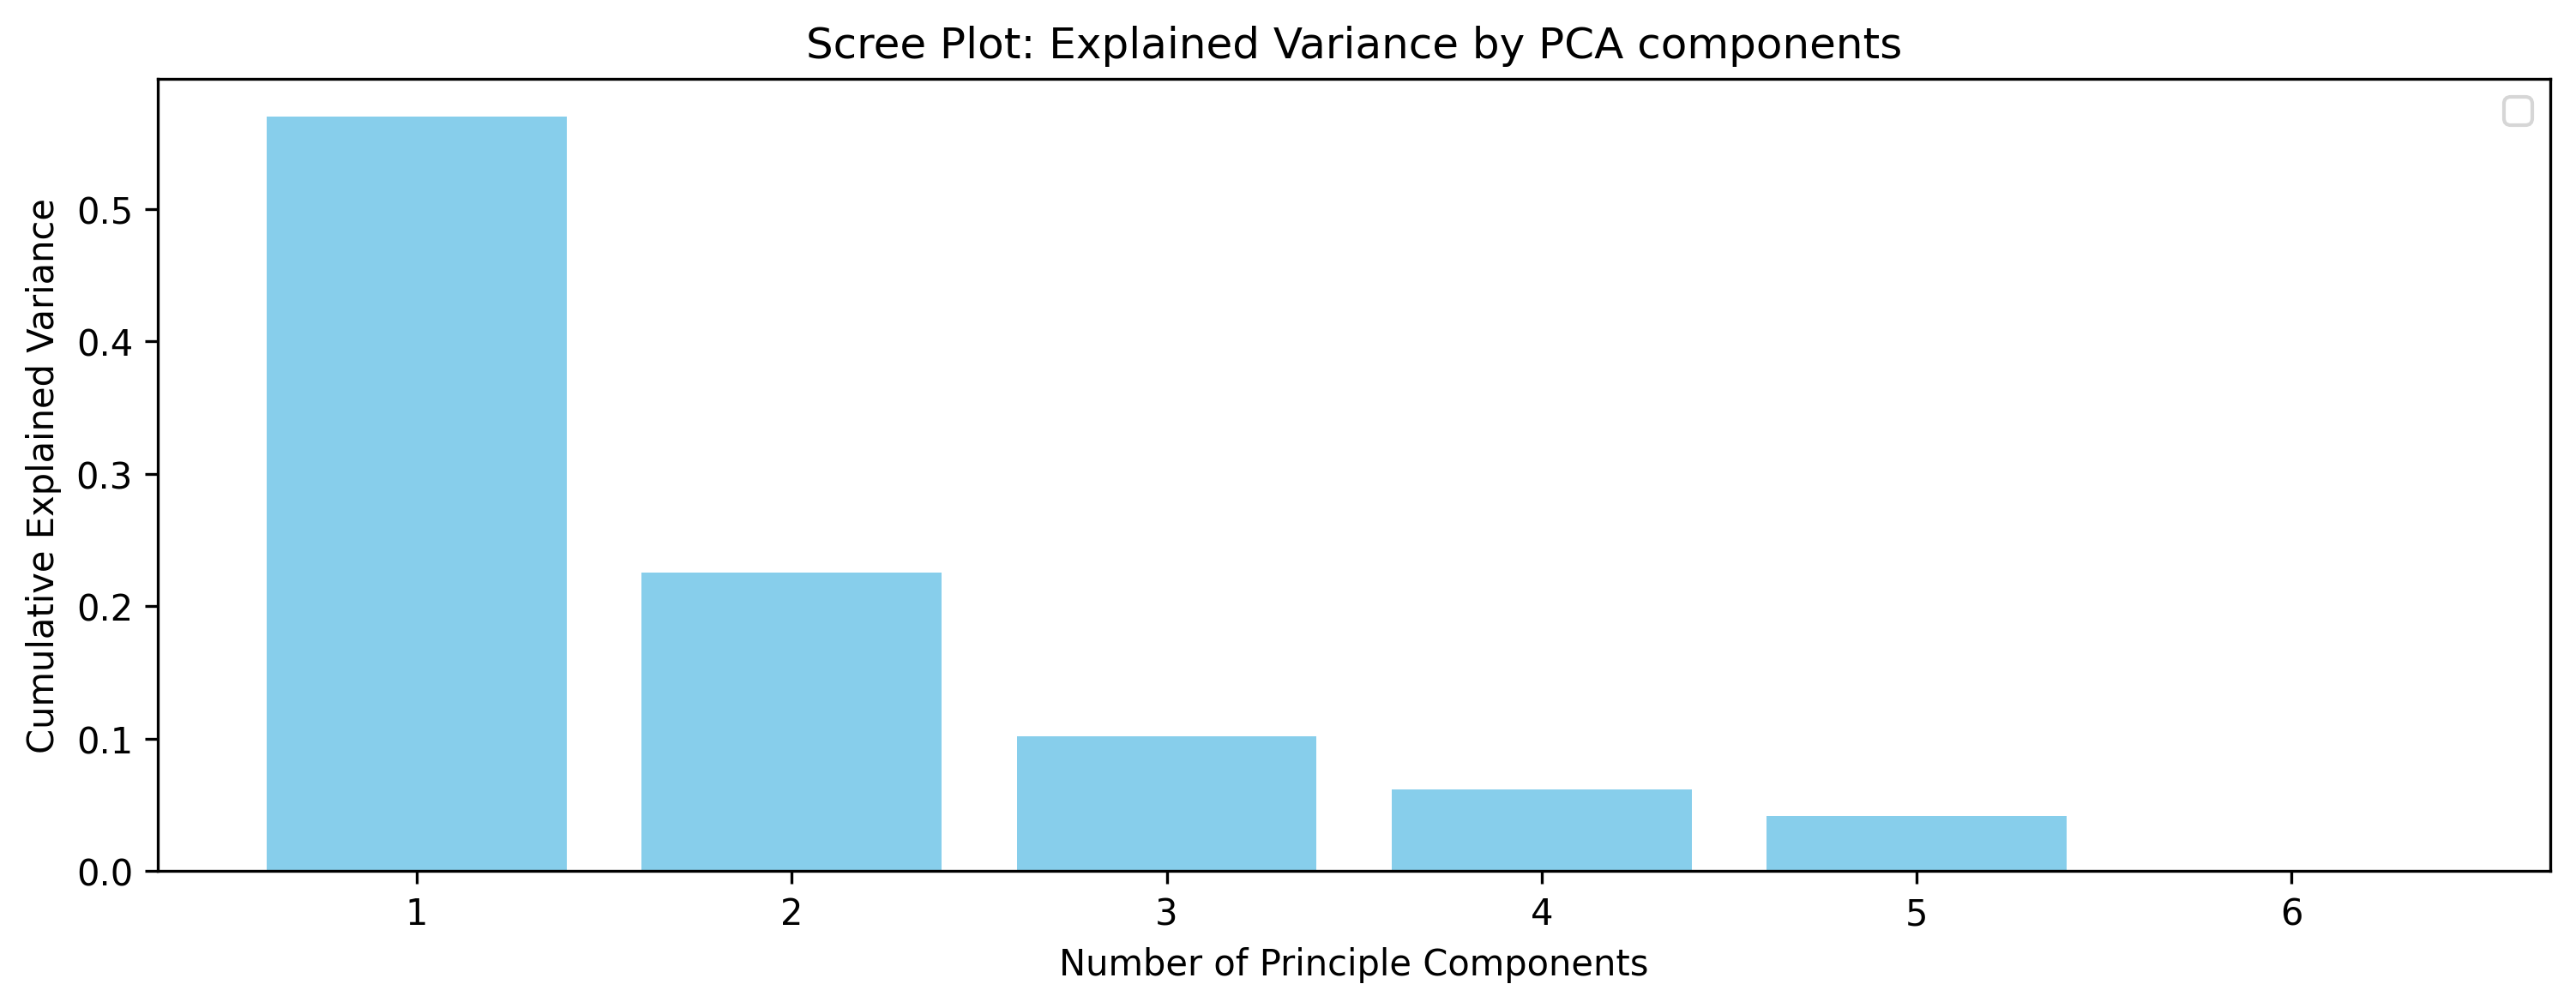

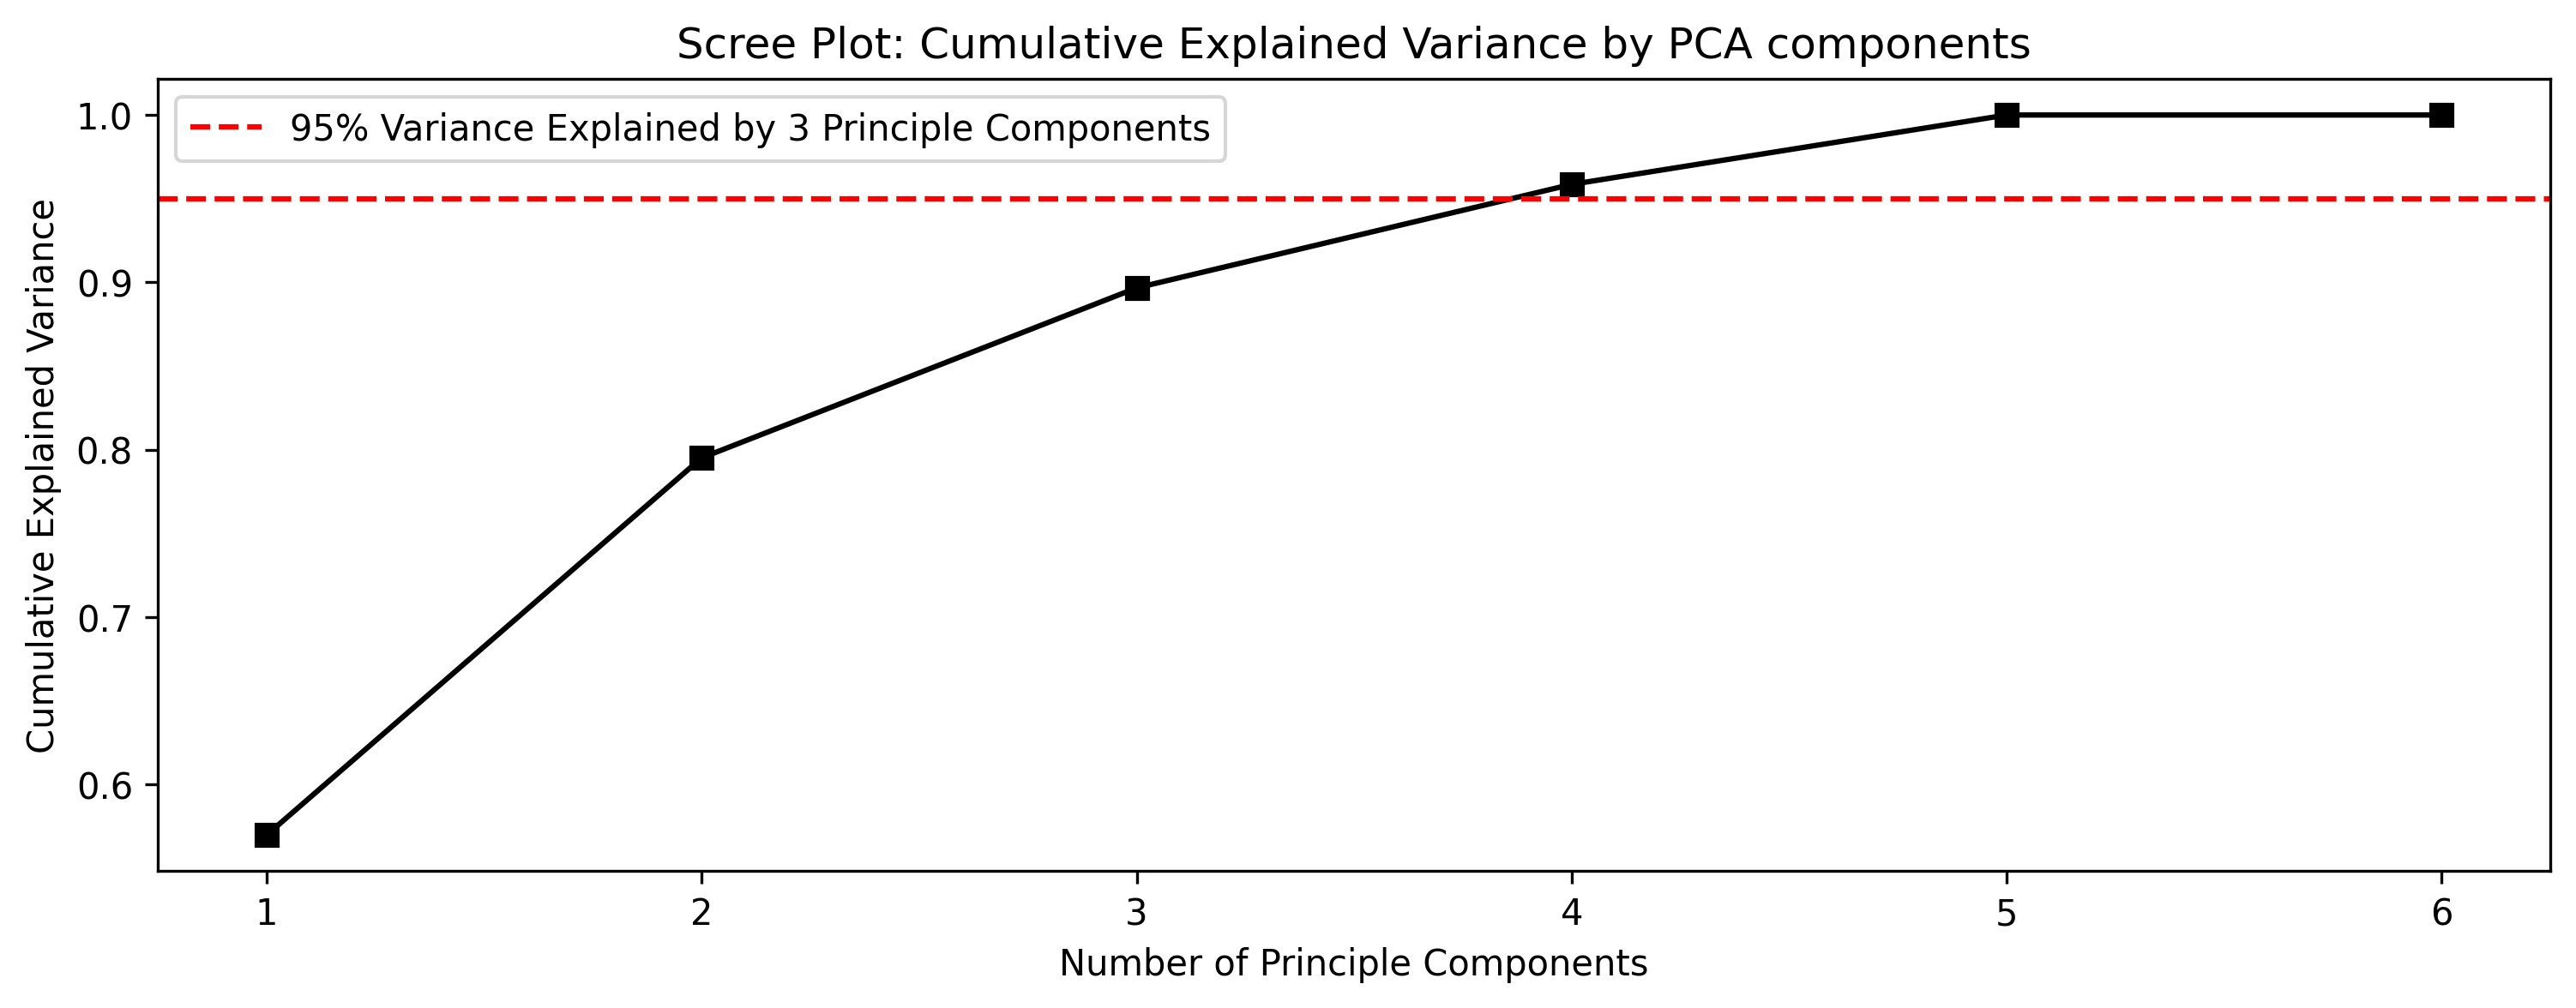

In [111]:
X = df.drop(["CustomerID"], axis = 1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA(random_state = 42)
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
x_axis = range(1, len(cumulative_variance) +1)

plt.figure(figsize = (12,4), dpi = 300)
plt.bar(x_axis, explained_variance, color = "skyblue")
plt.title("Scree Plot: Explained Variance by PCA components")
plt.xlabel("Number of Principle Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.show()

plt.figure(figsize = (12,4), dpi = 300)
plt.plot(x_axis, cumulative_variance, marker = 's', color = 'black')
plt.axhline(y = 0.95, linestyle = '--', color = 'red', label = "95% Variance Explained by 3 Principle Components")
plt.title("Scree Plot: Cumulative Explained Variance by PCA components")
plt.xlabel("Number of Principle Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.show()

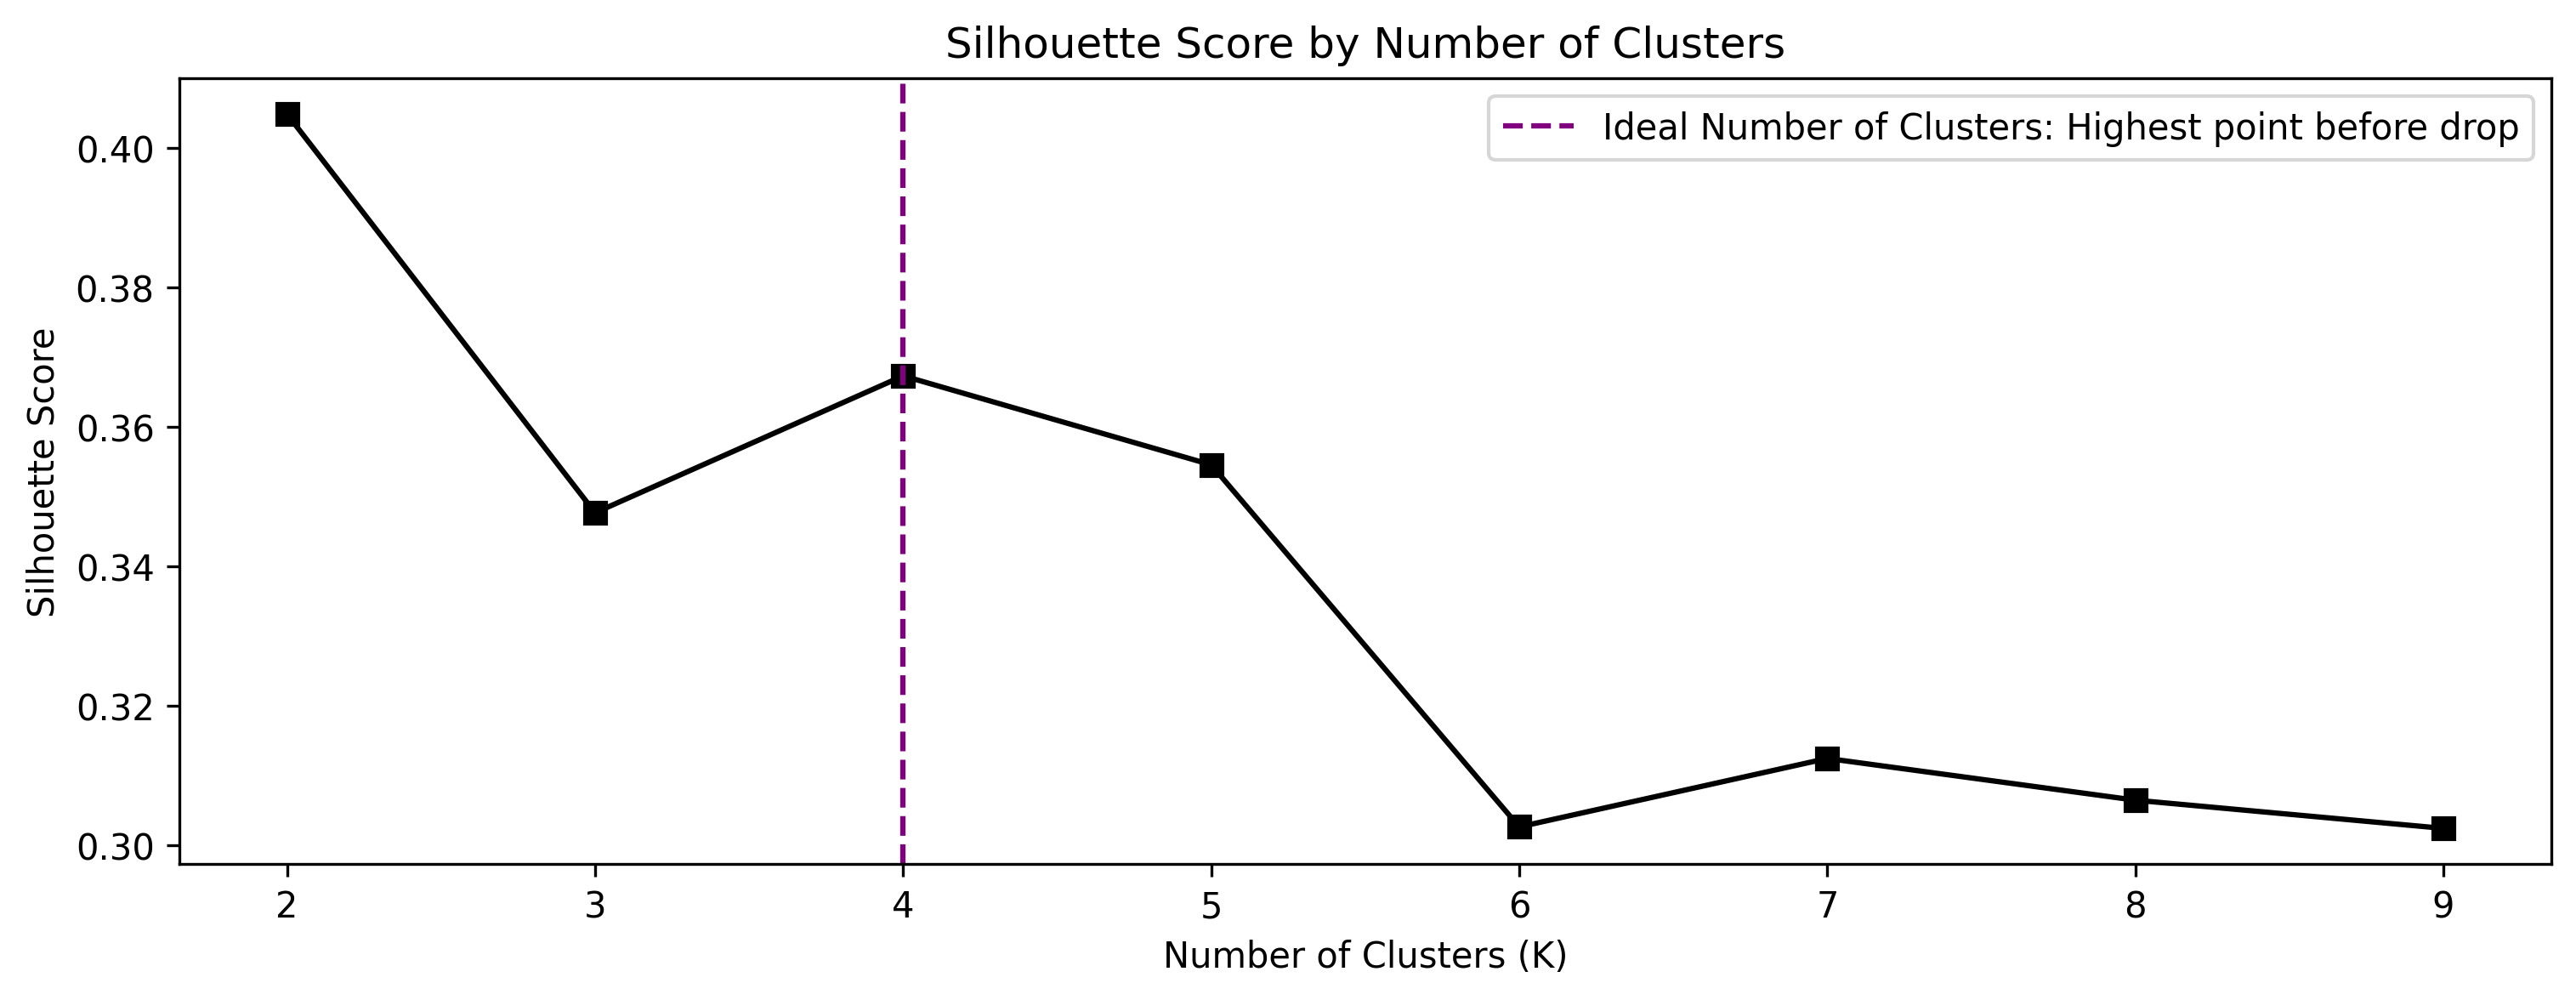

In [112]:
pca_components = 5

pca = PCA(n_components = pca_components, random_state = 42)

X_pca = pca.fit_transform(X_scaled)

k_range = range(2,10)

s_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    k_labels = kmeans.fit_predict(X_pca)
    sil_score = silhouette_score(X_pca, k_labels)
    s_scores.append(sil_score)

plt.figure(figsize = (12,4), dpi = 300)
plt.plot(k_range, s_scores, marker = 's', color = "black")
plt.axvline(x = 4, color = 'purple', linestyle = '--', label = "Ideal Number of Clusters: Highest point before drop")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.show()

KMeans model successfully saved to AWS S3

Model successfully loaded from AWS S3


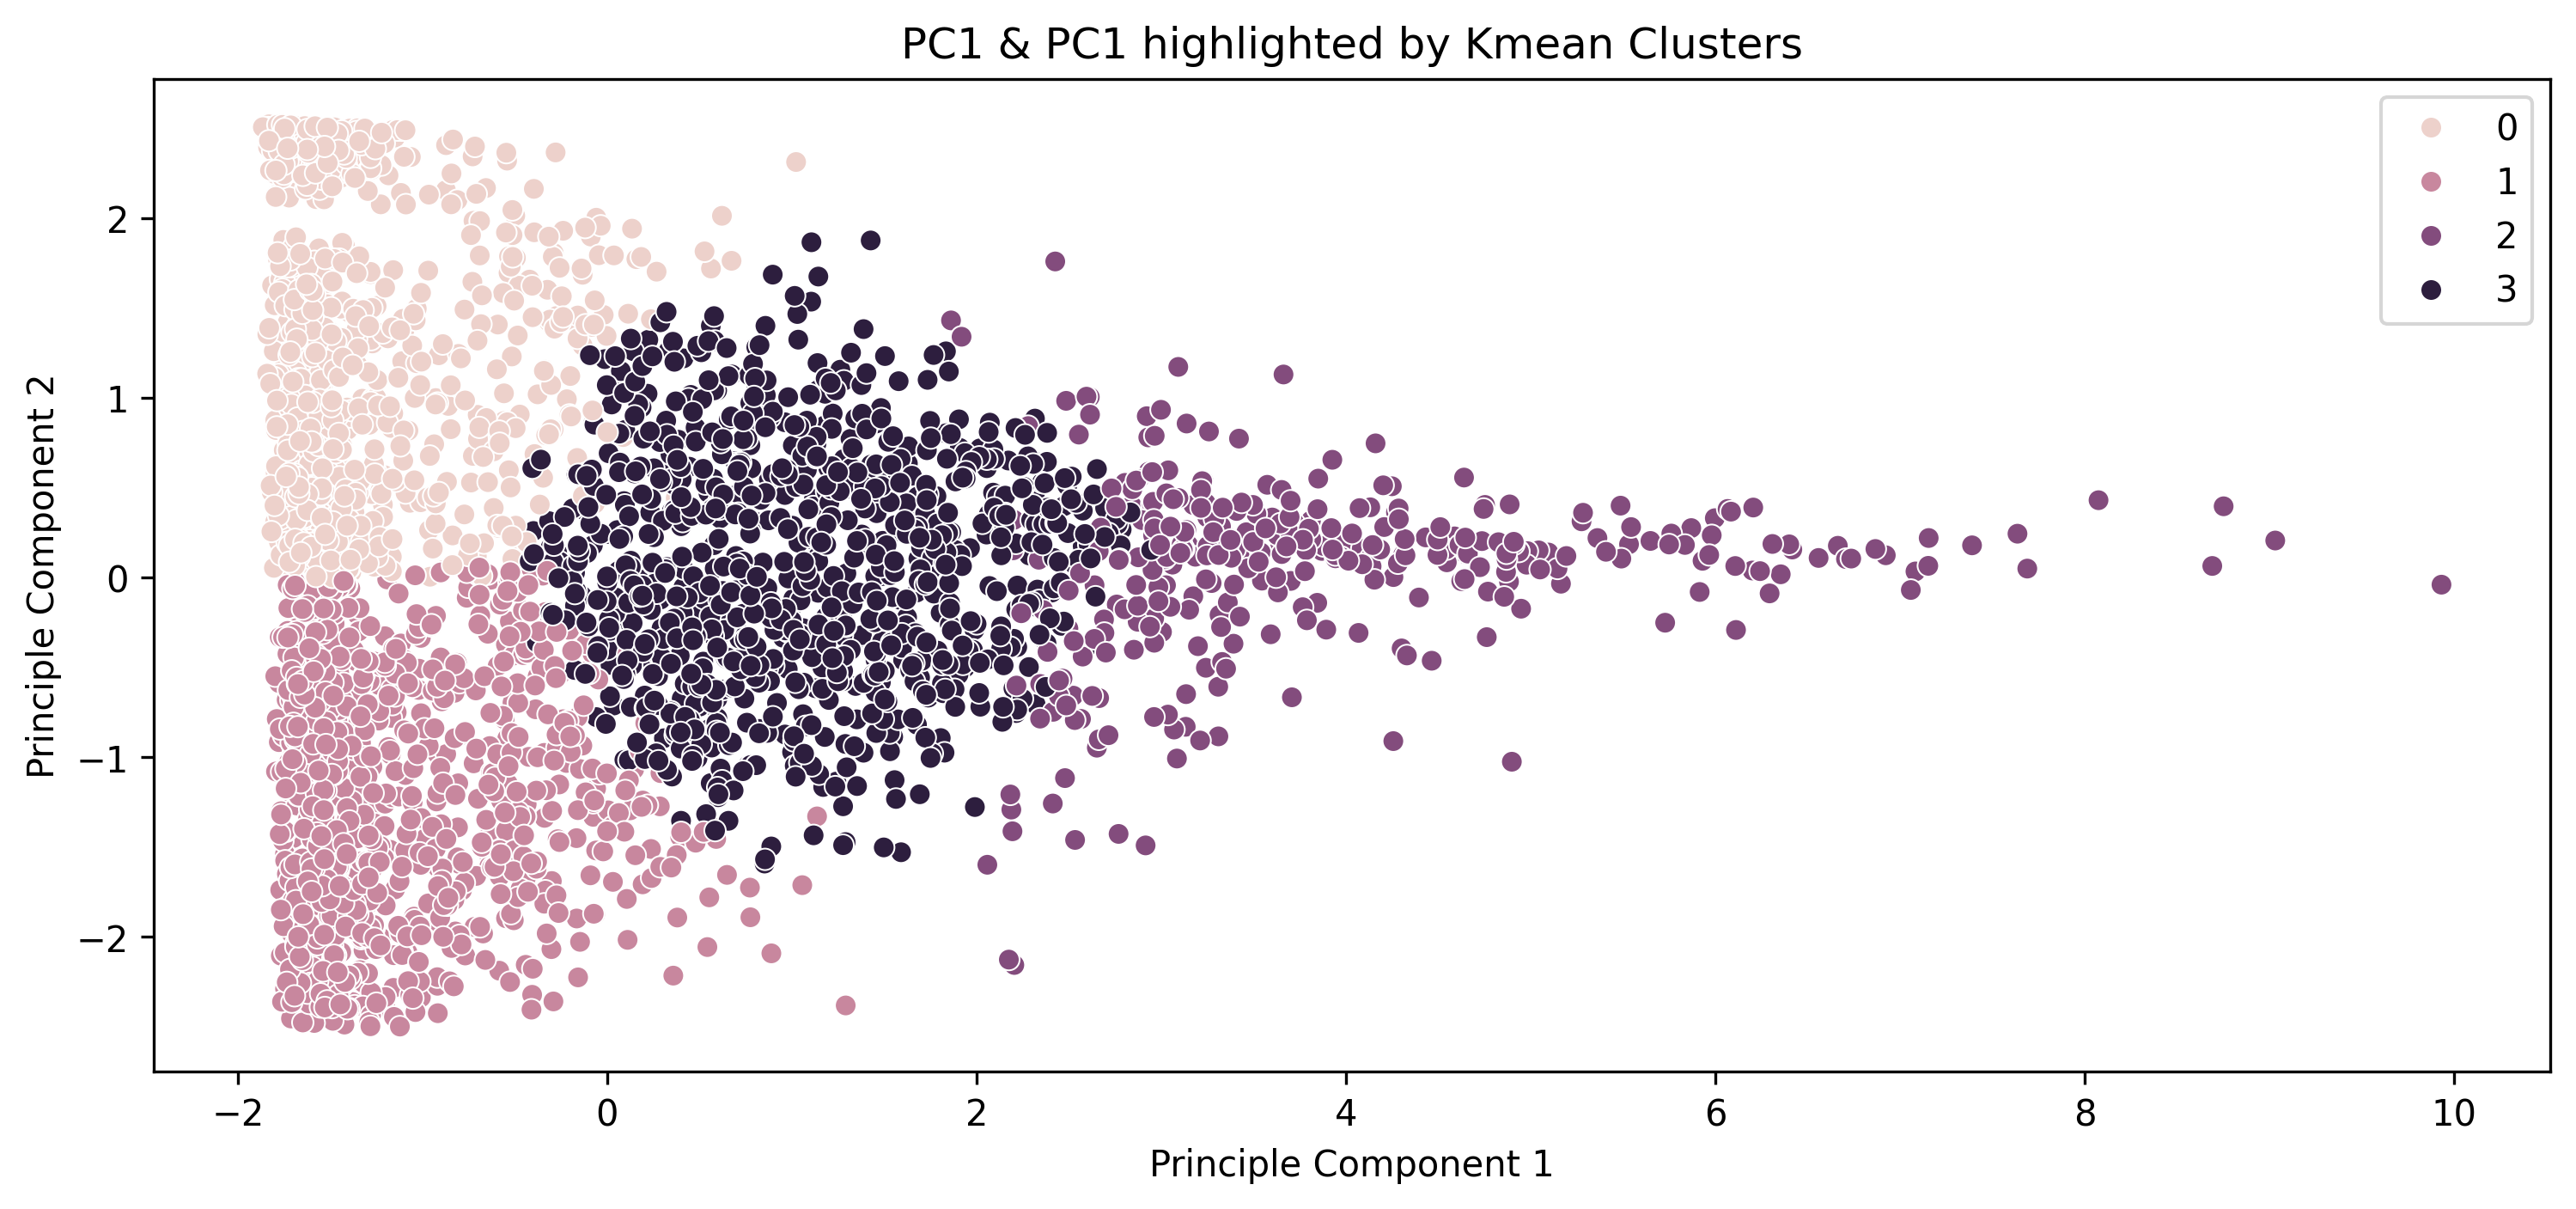

In [113]:
import joblib

ideal_clusters = 4

#After fitting model without outliers, and storing in drive, all data including outliers were fitted

pipeline_steps = [
   ('scaler', StandardScaler()),
   ('pca', PCA(n_components = pca_components, random_state = 42)),
   ('kmeans', KMeans(n_clusters = ideal_clusters, random_state = 42, n_init = 10))
]

pipeline = Pipeline(pipeline_steps)
pipeline.fit(X)

joblib.dump(pipeline, "kmeans_segmentation.joblib")
s3.upload_file("kmeans_segmentation.joblib", bucket_name, "predictive_models/kmeans_segmentation.joblib")
print(f'KMeans model successfully saved to AWS S3')

s3.download_file(bucket_name, "predictive_models/kmeans_segmentation.joblib", "kmeans_segmentation.joblib")

# For consistency, joblib file is pulled back to predict clusters
loaded_model = joblib.load("kmeans_segmentation.joblib")

print('\nModel successfully loaded from AWS S3')

k_labels = loaded_model.predict(X)

pc1 = X_pca[:,0]
pc2 = X_pca[:,1]

plt.figure(figsize = (12,5), dpi = 300)
sns.scatterplot(x = pc1, y = pc2, hue = k_labels)
plt.title("PC1 & PC1 highlighted by Kmean Clusters")
#plt.axhline(y = 2.4, color = "grey", linestyle = '--')
#plt.axvline(x = 0.3, color = "grey", linestyle = '--')
#plt.axvline(x = 5, color = "grey", linestyle = '--')
plt.xlabel("Principle Component 1")
plt.ylabel("Principle Component 2")
plt.show()

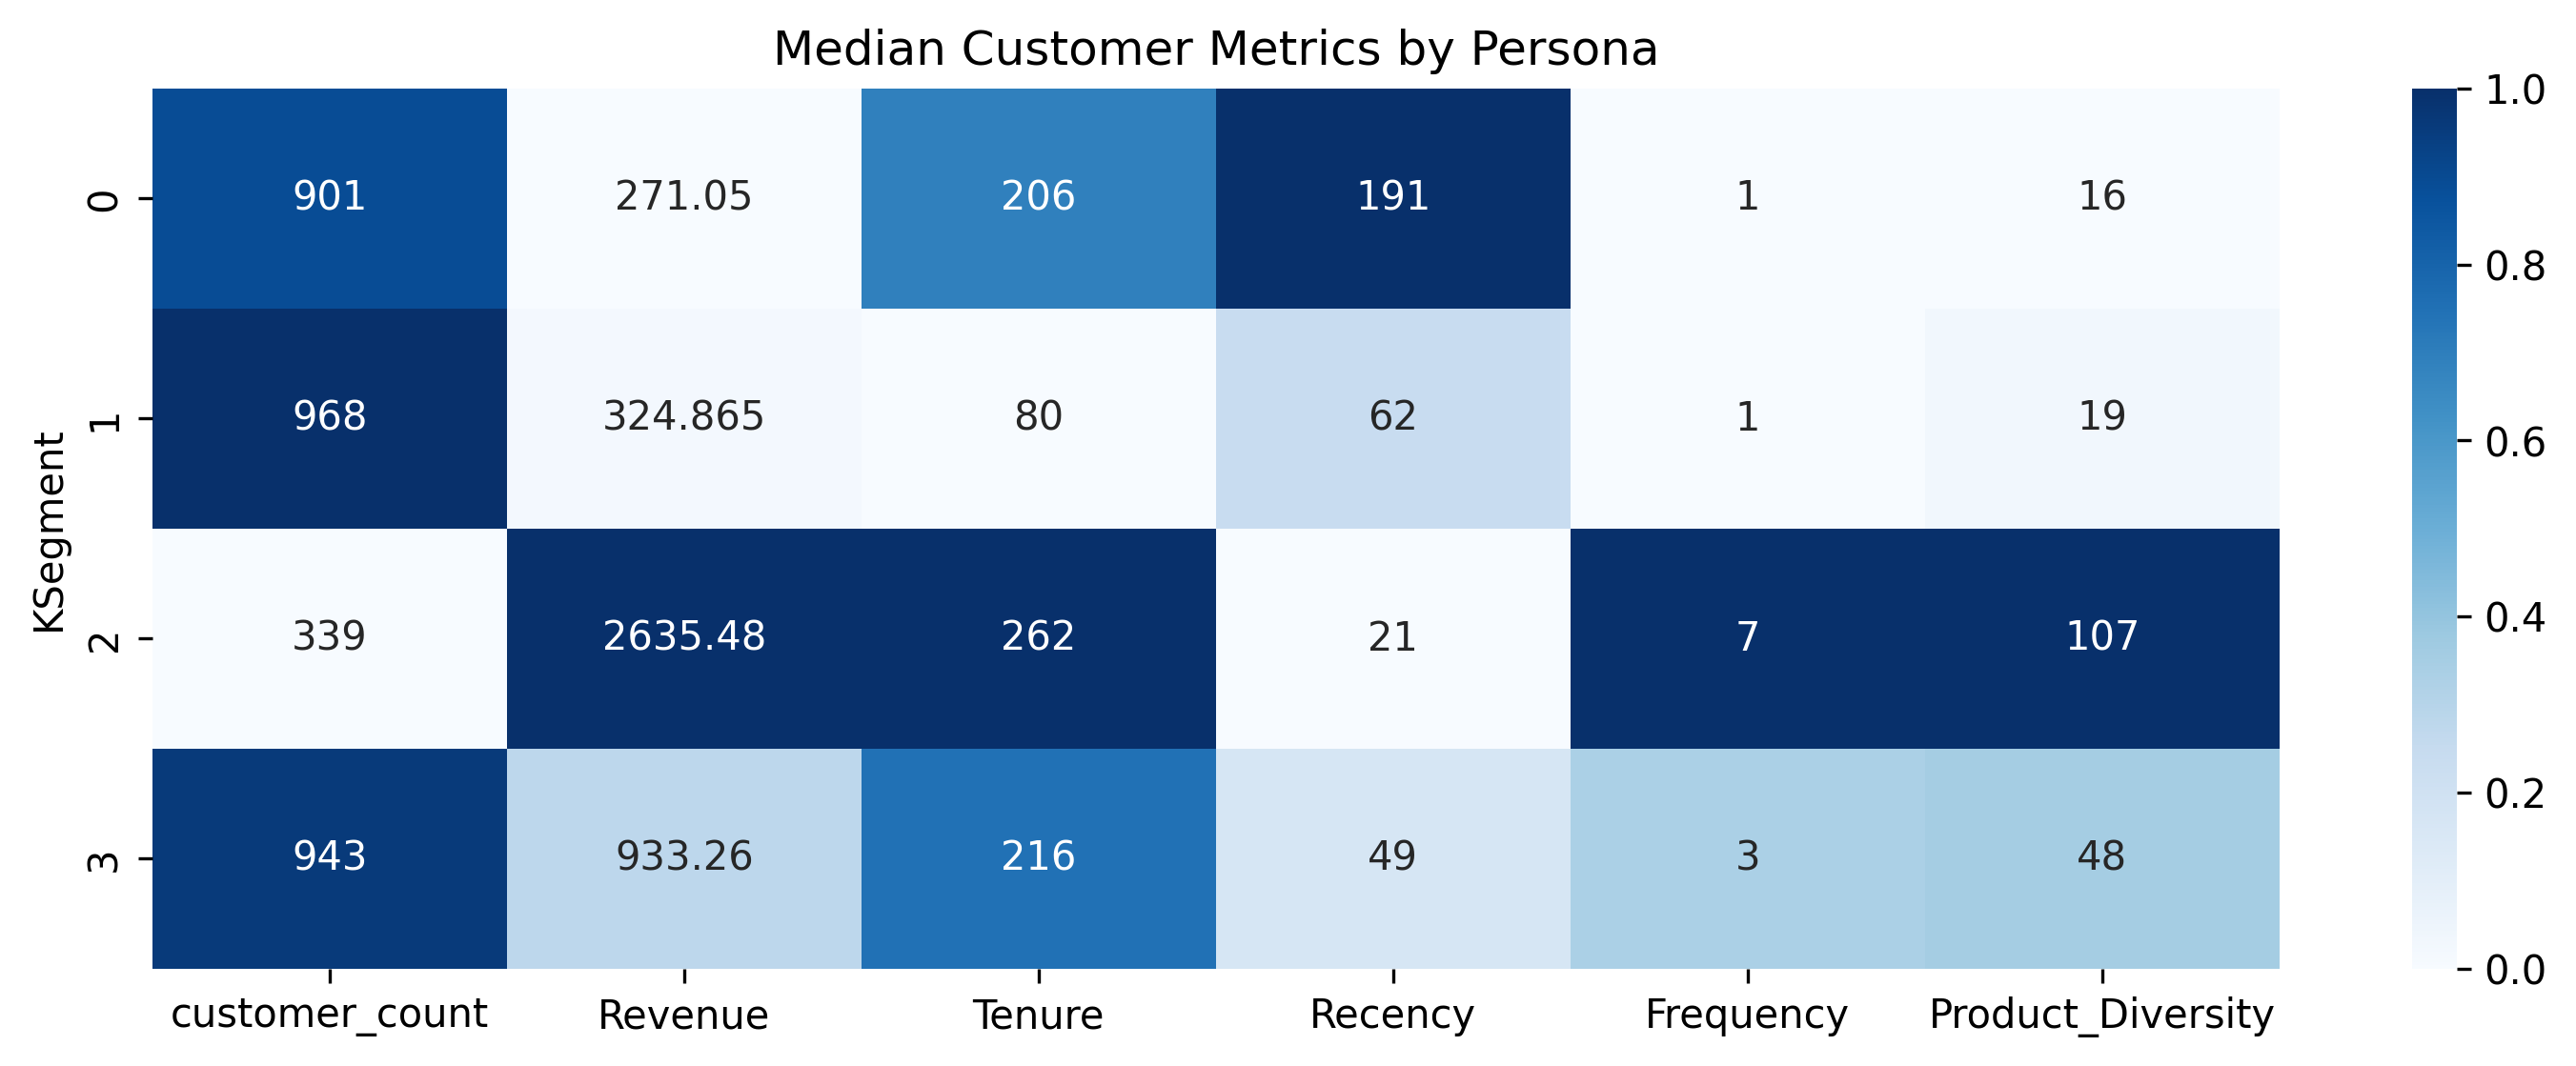

In [114]:
df["KSegment"] = k_labels

medians = df.groupby("KSegment").agg(
  customer_count = ("CustomerID", "count"),
  Revenue = ("TotalRevenue", "median"),
  Tenure = ("Tenure", "median"),
  Recency = ("Recency", "median"),
  Frequency = ("Frequency", "median"),
  Product_Diversity = ("ProductDiversity", "median"))

#medians = df.groupby("KSegment")[['Frequency', 'Recency', 'TotalRevenue', 'Tenure', 'ProductDiversity']].median()
medians_norm = (medians - medians.min())/(medians.max() - medians.min())

plt.figure(figsize = (12,4), dpi = 300)
sns.heatmap(data = medians_norm, annot = medians, fmt = 'g', cmap = 'Blues')
plt.title('Median Customer Metrics by Persona')
plt.show()

In [115]:
# Mapping defined segments to Database

query = """
--ALTER TABLE customer_segment_labels
--ADD COLUMN "Persona" VARCHAR(50);

UPDATE customer_segment_labels
SET "Persona" = CASE
     WHEN "KSegment" = 1 THEN 'Low Engagement Risk Group'
     WHEN "KSegment" = 3 THEN 'Loyal Performers'
     WHEN "KSegment" = 2 THEN 'High-Value Elite'
     WHEN "KSegment" = 0 THEN 'Lost & Inactive Customers'
     ELSE 'Not_assigned'
END

"""

with engine.begin() as conn:
    conn.execute(text(query))
print("Assigned Customer Persona to Kmean labels in v_customer_segment_labels Postgres View")


persona_mapping = {
    1: "Low Engagement Risk Group",
    3: "Loyal Performers",
    0: "Lost & Inactive Customers",
    2: "High-Value Elite"
}

df['Persona'] = df['KSegment'].map(persona_mapping)

Assigned Customer Persona to Kmean labels in v_customer_segment_labels Postgres View


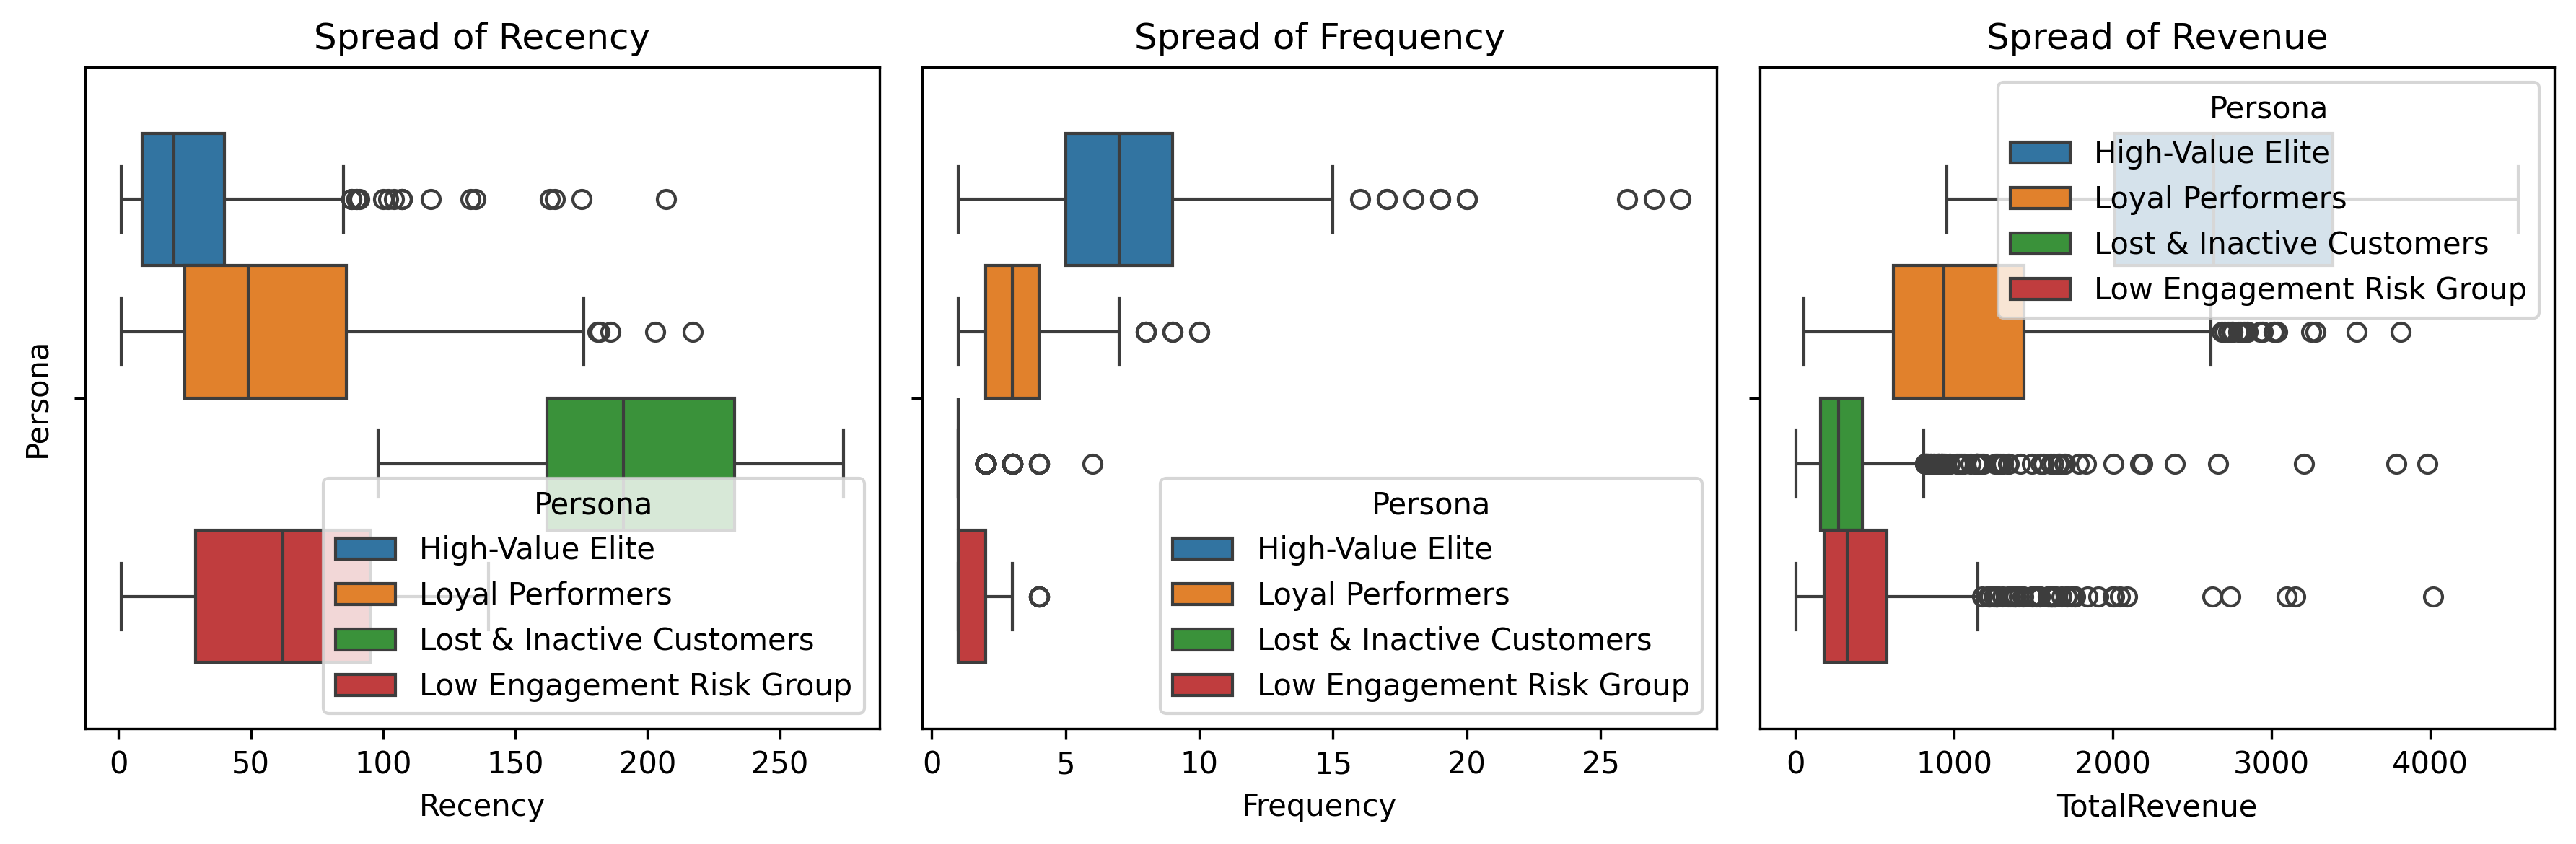

In [116]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, dpi = 300, figsize = (12,4))
sns.boxplot(data = df, x = "Recency", hue = "Persona", ax = ax1)
ax1.set_title("Spread of Recency")
ax1.set_ylabel("Persona")

sns.boxplot(data = df, x = "Frequency", hue = "Persona", ax = ax2)
ax2.set_title("Spread of Frequency")
ax1.set_ylabel("Persona")

sns.boxplot(data = df, x = "TotalRevenue", hue = "Persona", ax = ax3)
ax3.set_title("Spread of Revenue")
ax1.set_ylabel("Persona")

plt.tight_layout()
plt.show()

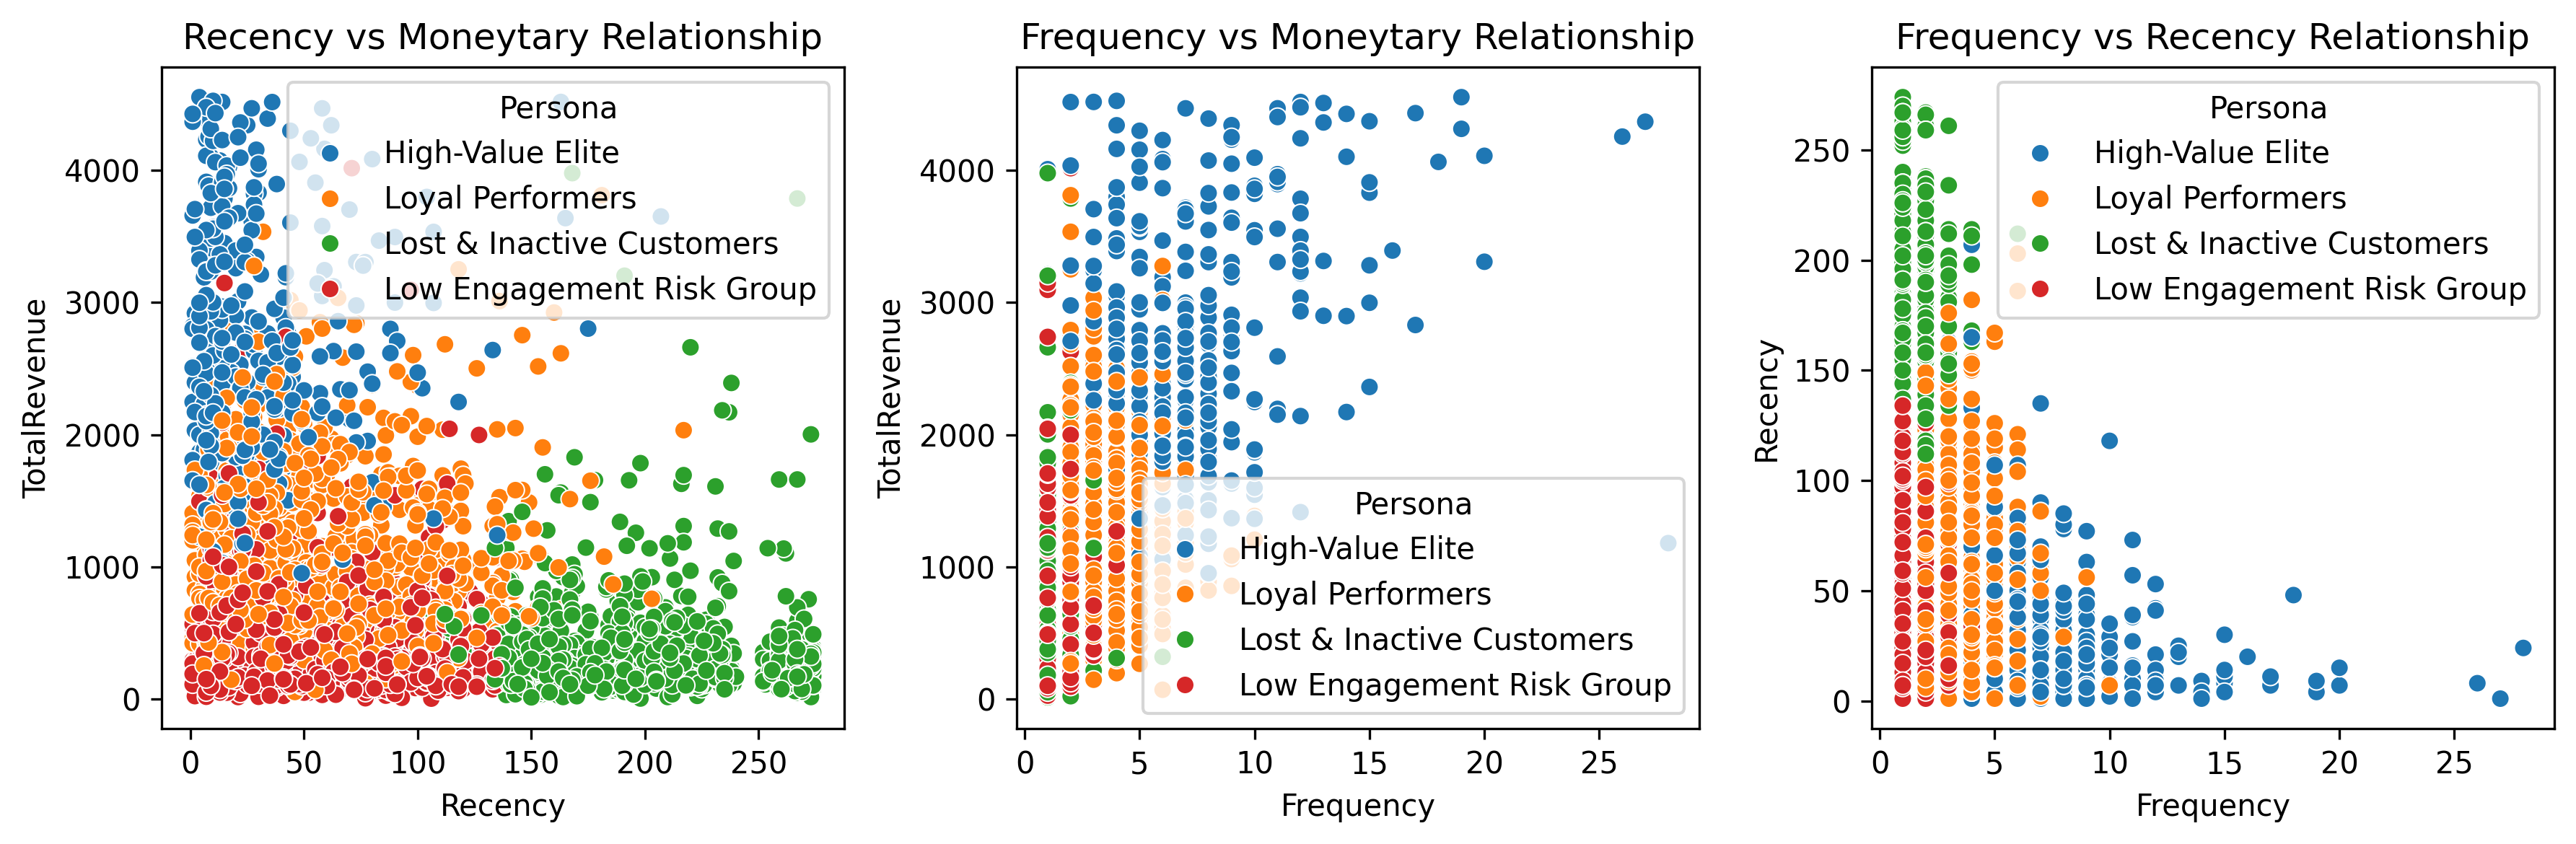

In [117]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, dpi = 300, figsize = (12,4))
sns.scatterplot(data = df, x = "Recency", y = "TotalRevenue", hue = "Persona", ax = ax1)
ax1.set_title("Recency vs Moneytary Relationship")
ax1.set_ylabel("TotalRevenue")

sns.scatterplot(data = df, x = "Frequency", y = "TotalRevenue", hue = "Persona", ax = ax2)
ax2.set_title("Frequency vs Moneytary Relationship")
ax2.set_ylabel("TotalRevenue")

sns.scatterplot(data = df, x = "Frequency", y = "Recency" , hue = "Persona", ax = ax3)
ax3.set_title("Frequency vs Recency Relationship")
ax3.set_ylabel("Recency")

plt.tight_layout()
plt.show()

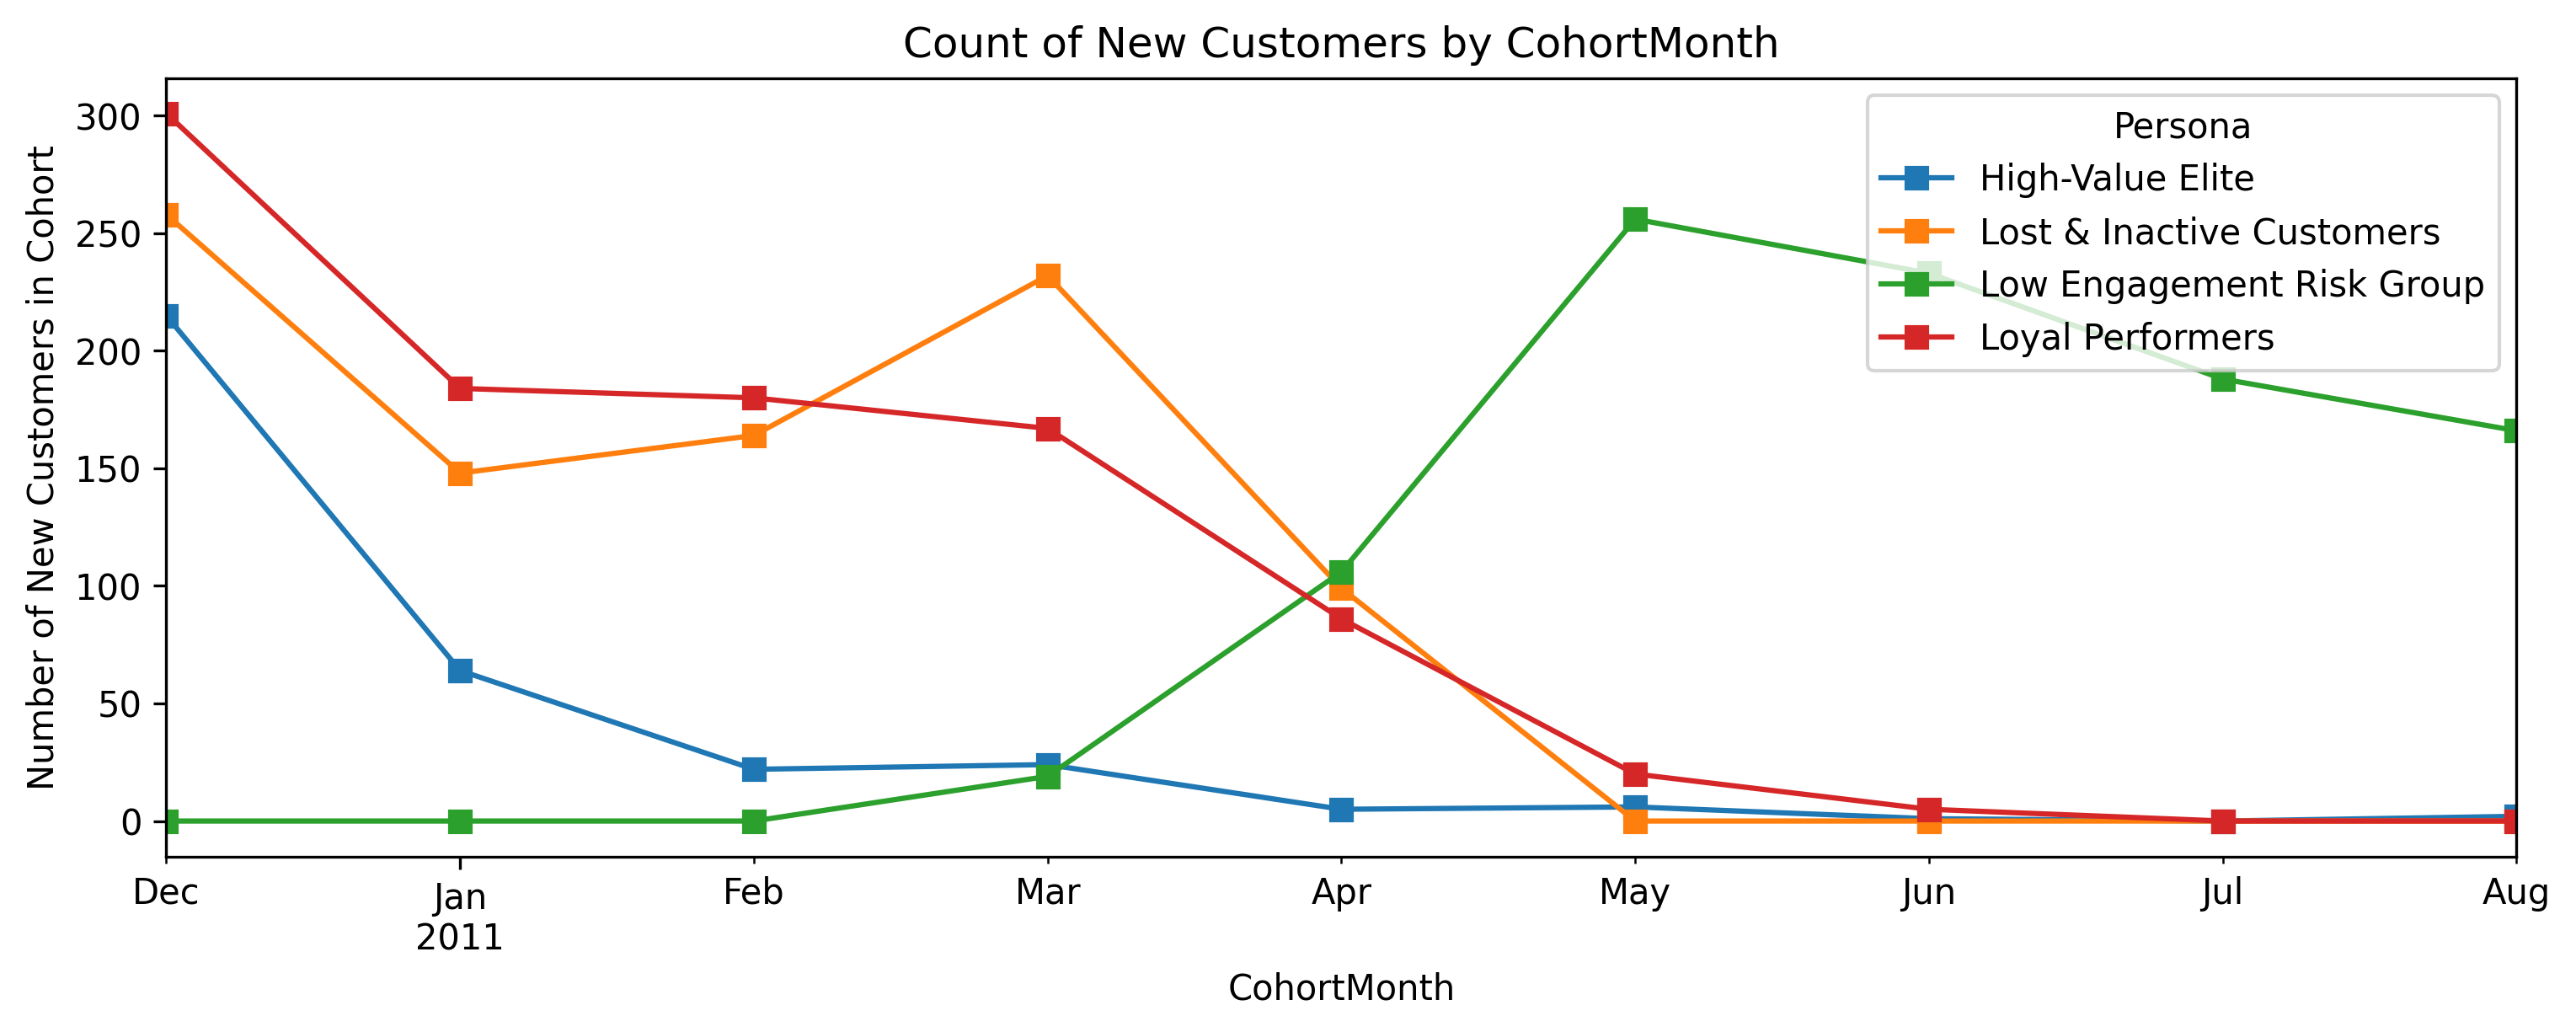


Number of New Client by CohortMonth


CohortMonth,2010-12,2011-01,2011-02,2011-03,2011-04,2011-05,2011-06,2011-07,2011-08
Persona,,,,,,,,,
High-Value Elite,215,64,22,24,5,6,1,0,2
Lost & Inactive Customers,258,148,164,232,99,0,0,0,0
Low Engagement Risk Group,0,0,0,19,106,256,233,188,166
Loyal Performers,301,184,180,167,86,20,5,0,0


In [118]:
df = df.merge(cohort_df, on = "CustomerID", how = 'left')
crosstab_persona  = pd.crosstab(df["CohortMonth"], df["Persona"])

crosstab_norm = (crosstab_persona - crosstab_persona.min())/(crosstab_persona.max() - crosstab_persona.min())

fig, ax = plt.subplots(1,1,figsize = (12,4), dpi = 300)
crosstab_persona.plot(kind = "line", marker = 's', ax = ax)
#sns.heatmap(data = crosstab_norm,annot = crosstab_persona, ax = ax, fmt = 'g', cmap = "Blues")
ax.set_ylabel("Number of New Customers in Cohort")
plt.title("Count of New Customers by CohortMonth")
plt.show()

print("\nNumber of New Client by CohortMonth")
crosstab_persona.transpose()

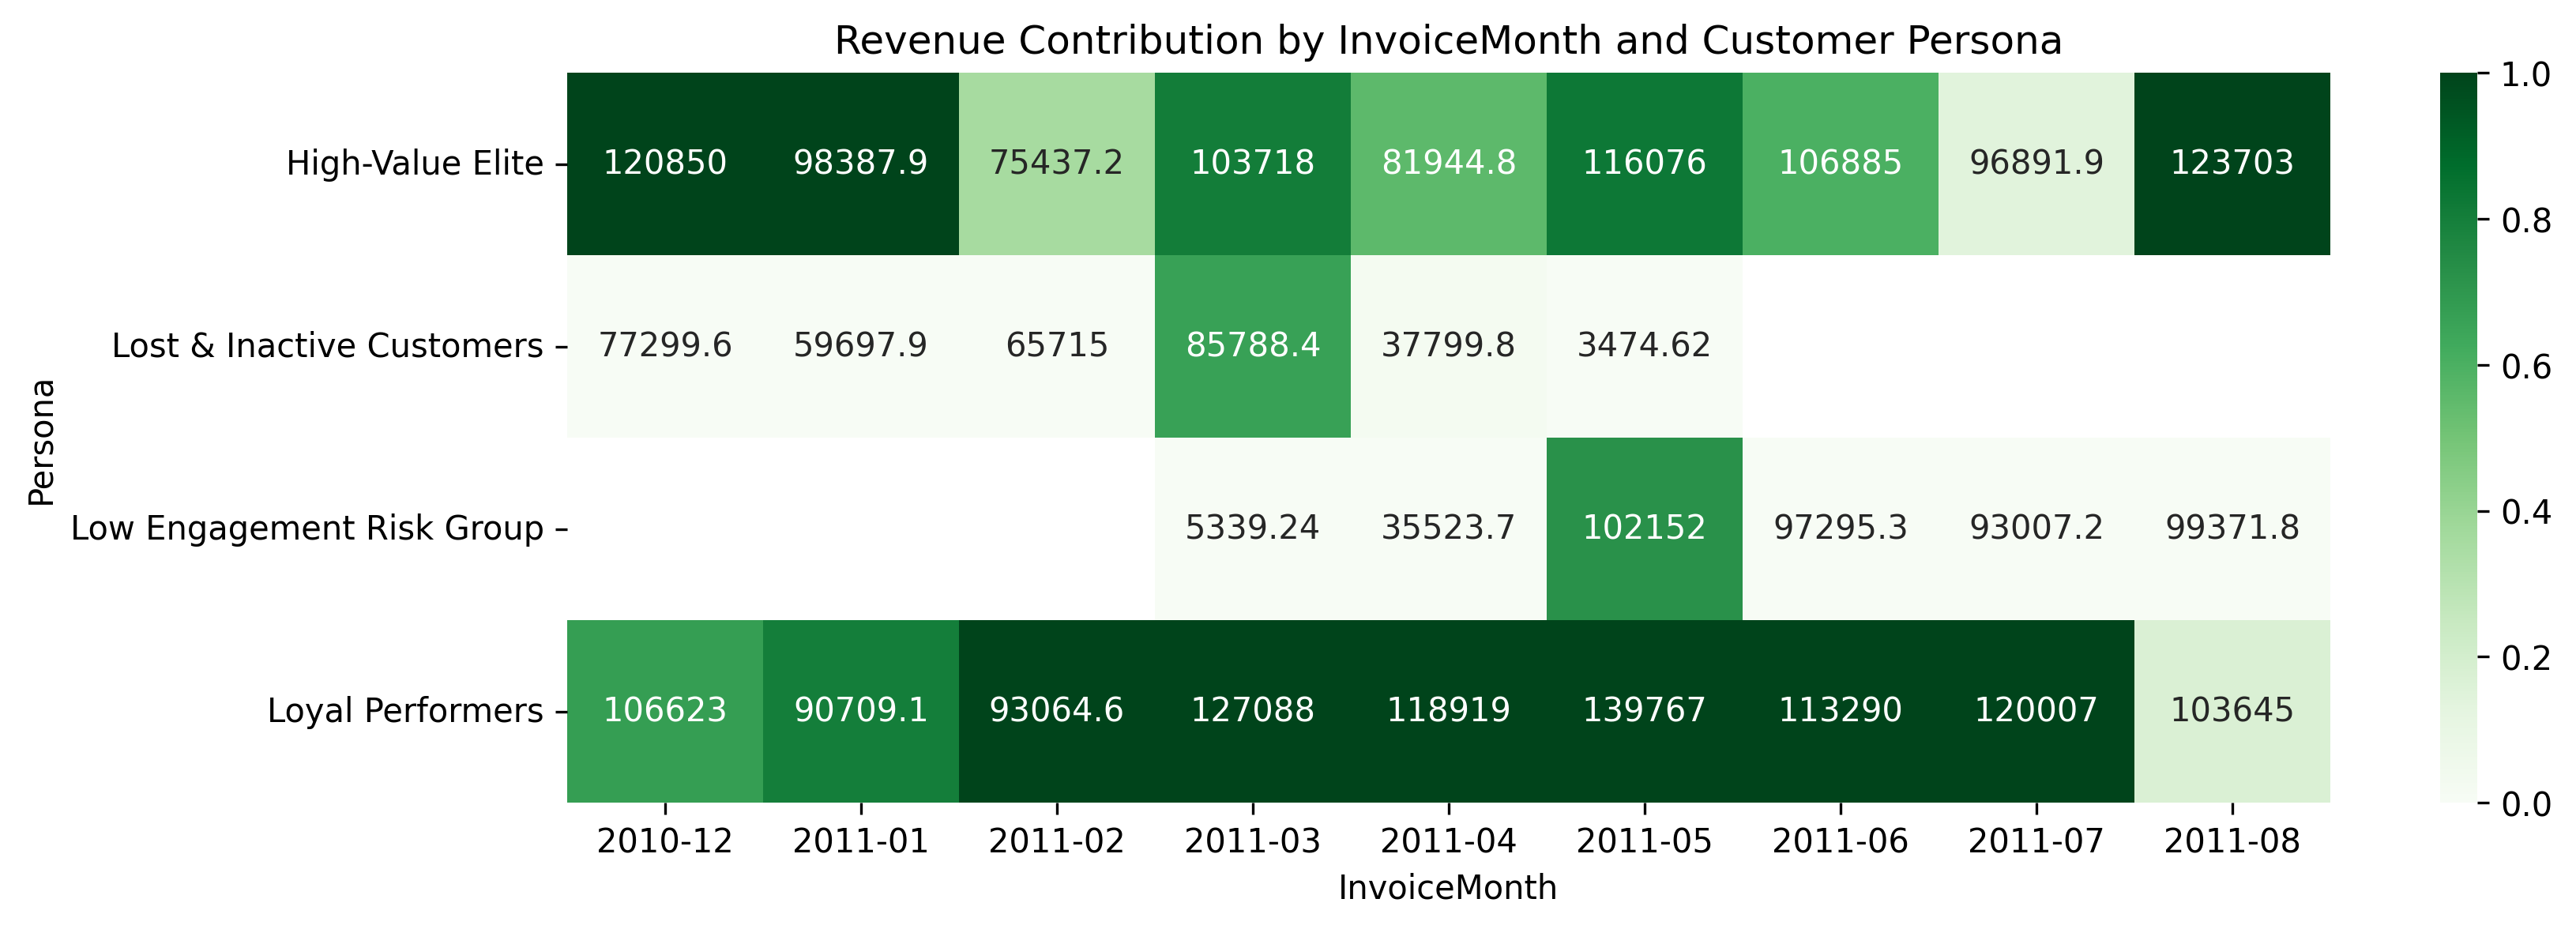

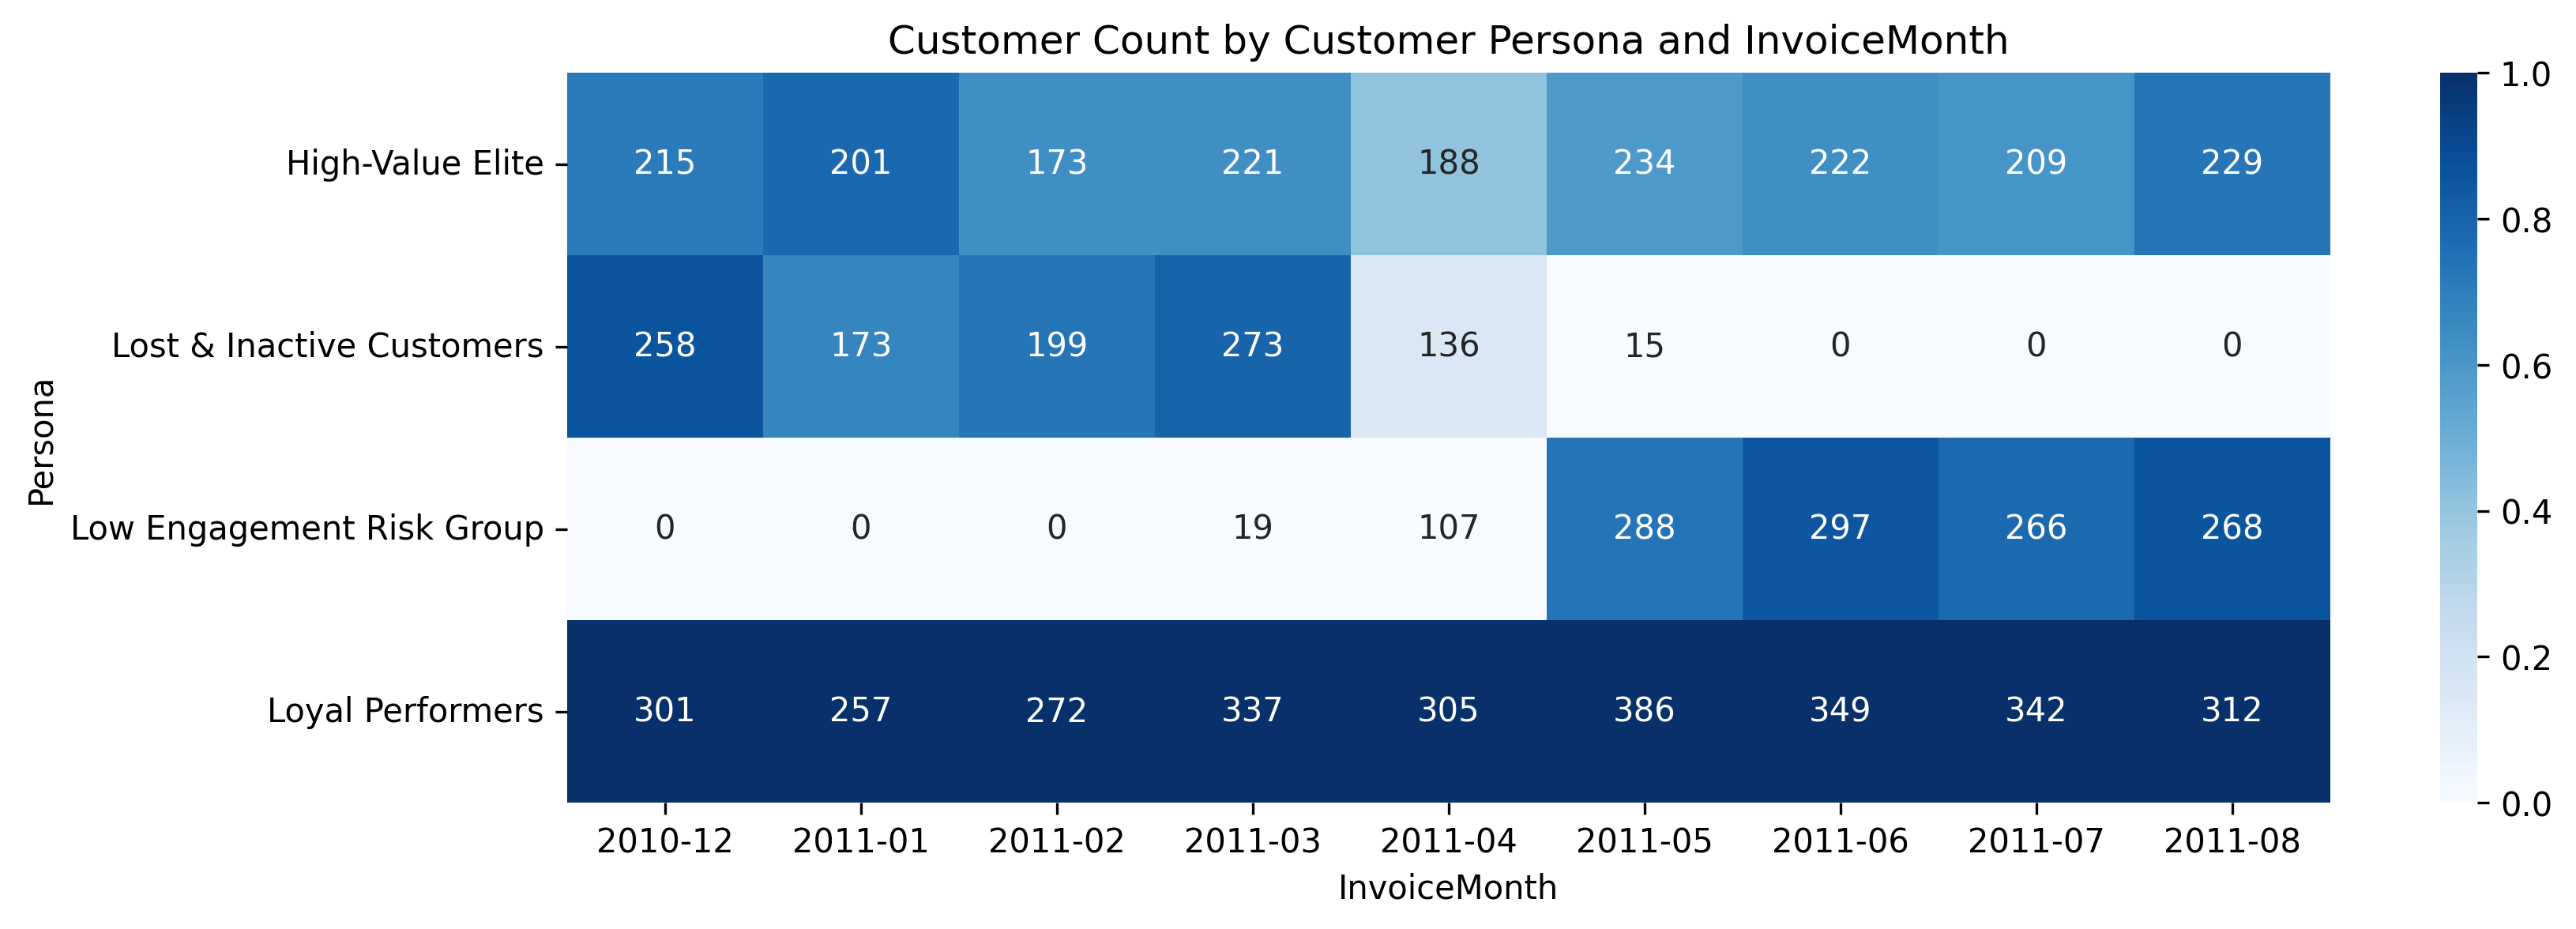

In [130]:

data = df_all[["CustomerID","Revenue", "InvoiceDate"]].merge(df[["CustomerID", "Persona"]], how = "left", on = "CustomerID")

data["InvoiceMonth"] = data["InvoiceDate"].dt.to_period("M")

summary = data.groupby(["Persona","InvoiceMonth"])["Revenue"].sum().reset_index()

summary1 = summary.pivot_table(index = "Persona", columns = "InvoiceMonth", values = "Revenue", aggfunc = "sum")

summary_norm = (summary1 - summary1.min())/(summary1.max() - summary1.min())

plt.figure(figsize = (12,4), dpi = 300)
sns.heatmap(data = summary_norm, annot = summary1, cmap = "Greens", fmt = 'g')
plt.title("Revenue Contribution by InvoiceMonth and Customer Persona")
plt.show()

data = data.groupby(["CustomerID","Persona","InvoiceMonth"]).size().reset_index()
crosstab = pd.crosstab(data["Persona"], data["InvoiceMonth"])

crosstab_norm = (crosstab - crosstab.min())/(crosstab.max() - crosstab.min())

plt.figure(figsize = (12,4), dpi = 300)
sns.heatmap(data = crosstab_norm, annot = crosstab, cmap = "Blues", fmt = 'g')
plt.title("Customer Count by Customer Persona and InvoiceMonth")
plt.show()